# 03 — Formation control

Non-zero offsets: rigid formations, leader-follower tracking, and formation morphing.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import distributed_mpc_admm
from distributed_mpc_admm import (
    ADMMOptions,
    ConsensusADMM,
    DistributedMPC,
    MPCOptions,
    SimulationLog,
    plotting,
)
from distributed_mpc_admm.communication_graph import CommunicationGraph
from distributed_mpc_admm.formation_constraints import (
    FormationSpec,
    LeaderFollowerSpec,
    formation_error,
    interpolate_formations,
)
from distributed_mpc_admm.per_agent_solver import (
    AgentCostWeights,
    AgentLimits,
    CvxpyAgentSolver,
    DoubleIntegrator,
)

plotting.apply_style("notebook")
rng = np.random.default_rng(0)

repo_root = Path(distributed_mpc_admm.__file__).resolve().parent.parent.parent

# Shared model and mission tuning.
model = DoubleIntegrator(dt=0.1, dim=2)
limits = AgentLimits()
formation_weights = AgentCostWeights(q_position=0.0, p_terminal=0.0)  # no external reference
admm_options = ADMMOptions(rho=1.0, max_iterations=300, eps_abs=2e-2, eps_rel=2e-2)
mpc_options = MPCOptions(horizon=10, dt=0.1, n_steps=60, seed=0)

# Scattered start, clearly away from the target square.
x0 = np.zeros((4, model.n_states))
x0[:, : model.dim] = [[3.0, 2.0], [-2.0, 2.5], [-2.5, -2.0], [2.0, -2.5]]

## Rigid square

Four agents to a 2 m square from scattered initial conditions.

{'mean_admm_iterations': 5.35, 'max_admm_iterations': 142.0, 'final_formation_error': 0.00695987681037041, 'settling_step': 19.0, 'total_solve_time': 3.601216487999409, 'convergence_failures': 0.0}


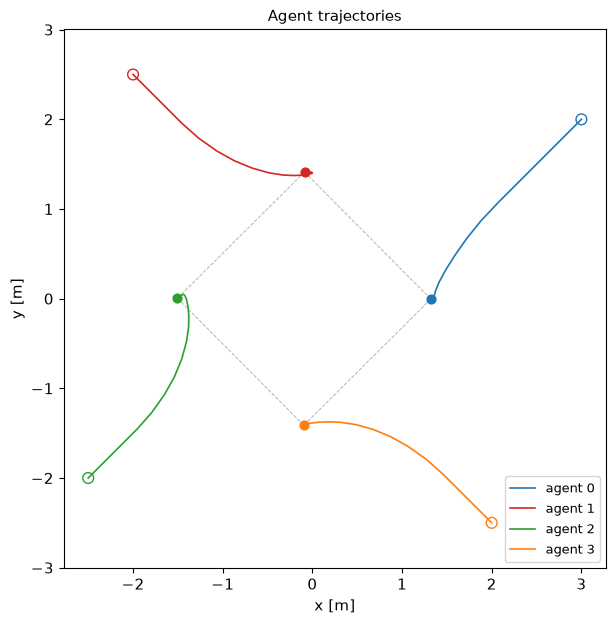

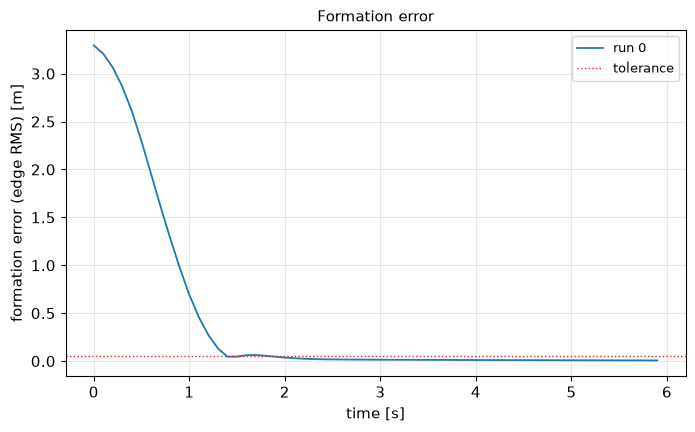

saved /repo/media/4_agent_formation.gif


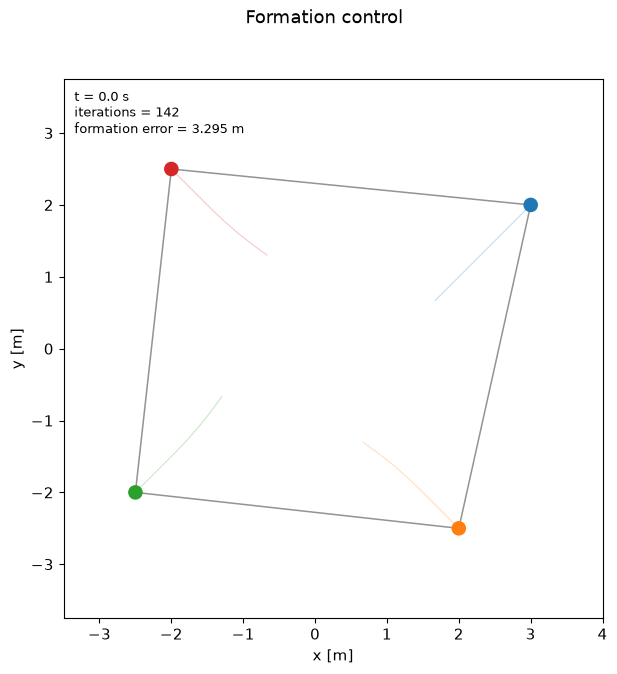

In [2]:
# Four agents to a 2 m square (radius 1.41 => side ~2 m).
formation = FormationSpec.regular_polygon(4, radius=1.41)

mpc = DistributedMPC(
    model,
    formation.graph,
    formation,
    limits,
    formation_weights,
    admm_options,
    mpc_options,
)
log_square = mpc.run(x0)

print(log_square.summary())
plotting.plot_trajectories(log_square, formation=formation)
plt.show()
plotting.plot_formation_error(log_square, tolerance=0.05)
plt.show()

# Canonical README hero: four agents converging to a square with edges overlaid.
anim = plotting.animate_formation(
    log_square, formation=formation, show_graph=True, show_predictions=True
)
plotting.save_animation(anim, str(repo_root / "media" / "4_agent_formation.gif"))
print(f"saved {repo_root / 'media' / '4_agent_formation.gif'}")

## Does the graph need to be the formation graph?

Run the same square with a cycle comm graph and with a complete comm graph. Compare settling time against algebraic connectivity.

cycle   : lambda_2 = 2.000, settling_step = 19


complete: lambda_2 = 4.000, settling_step = 20


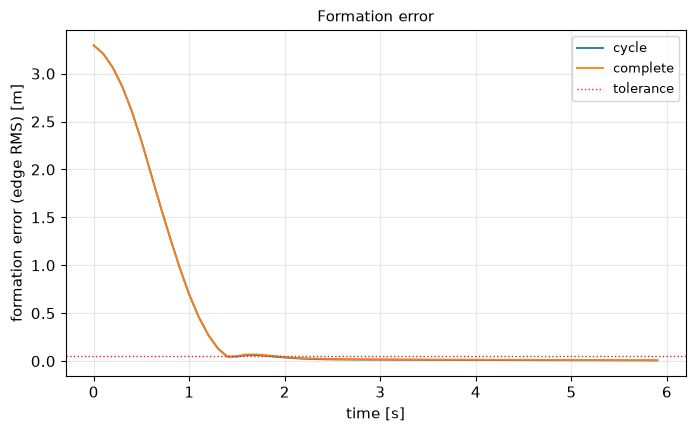

In [3]:
formation = FormationSpec.regular_polygon(4, radius=1.41)

logs = {}
lambda2 = {}
for name, comm in (
    ("cycle", CommunicationGraph.cycle(4)),
    ("complete", CommunicationGraph.complete(4)),
):
    ctrl = DistributedMPC(
        model, comm, formation, limits, formation_weights, admm_options, mpc_options
    )
    logs[name] = ctrl.run(x0)
    lambda2[name] = comm.algebraic_connectivity()
    print(
        f"{name:8s}: lambda_2 = {lambda2[name]:.3f}, "
        f"settling_step = {logs[name].summary()['settling_step']:.0f}"
    )

plotting.plot_formation_error(
    [logs["cycle"], logs["complete"]], labels=["cycle", "complete"], tolerance=0.05
)
plt.show()

## Leader-follower

Agent 0 tracks a moving reference; the rest carry only edge costs.

steady-state centroid lag (mean over last 20%): 1.304 m


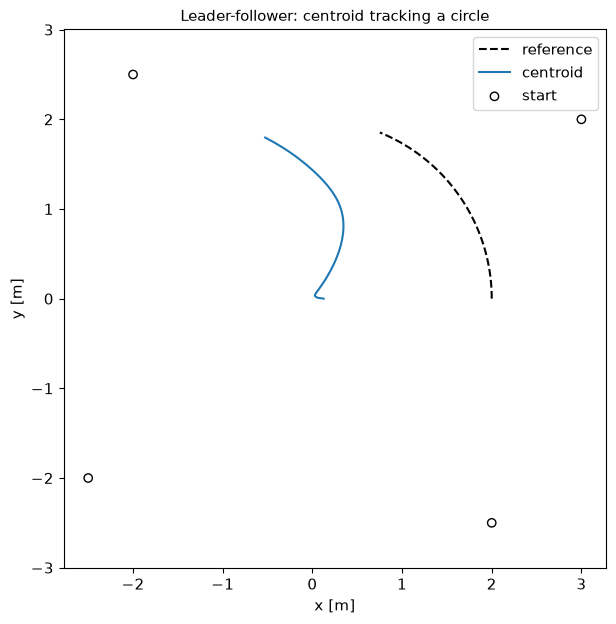

In [4]:
formation = FormationSpec.regular_polygon(4, radius=1.41)

t = 0.1 * np.arange(80)
reference = np.column_stack([2.0 * np.cos(0.15 * t), 2.0 * np.sin(0.15 * t)])  # circle
leader_follower = LeaderFollowerSpec(leaders=(0,), reference=reference)
tracking_weights = AgentCostWeights(q_position=1.0, p_terminal=5.0)

ctrl = DistributedMPC(
    model,
    formation.graph,
    formation,
    limits,
    tracking_weights,
    admm_options,
    MPCOptions(horizon=10, dt=0.1, n_steps=80, seed=0),
    leader_follower=leader_follower,
)
log_lf = ctrl.run(x0)

centroid = log_lf.positions[: len(reference)].mean(axis=1)
lag = np.linalg.norm(centroid - reference, axis=1)
held_lag = lag[-int(0.2 * len(lag)) :].mean()
print(f"steady-state centroid lag (mean over last 20%): {held_lag:.3f} m")

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(reference[:, 0], reference[:, 1], "k--", label="reference")
ax.plot(centroid[:, 0], centroid[:, 1], color="tab:blue", label="centroid")
ax.scatter(
    log_lf.positions[0, :, 0],
    log_lf.positions[0, :, 1],
    c="none",
    edgecolors="k",
    label="start",
)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="datalim")
ax.set_title("Leader-follower: centroid tracking a circle")
ax.legend()
plt.show()

## Rigidity matters

Repeat leader-follower on a path graph. The shape is preserved but the framework is flexible -- show `is_infinitesimally_rigid` returning False and the corresponding shear in the trajectory plot.

is_infinitesimally_rigid: False
rank R = 3 (need 5 for rigidity; 3 trivial motions)
rigidity_eigenvalue = 1.075e-16


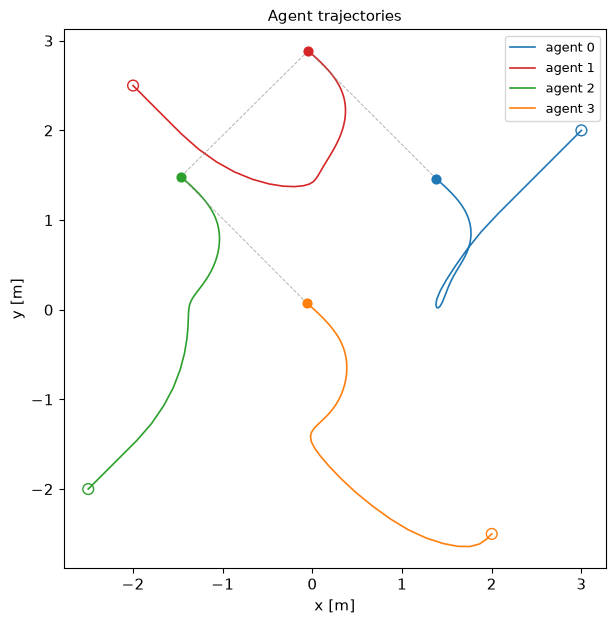

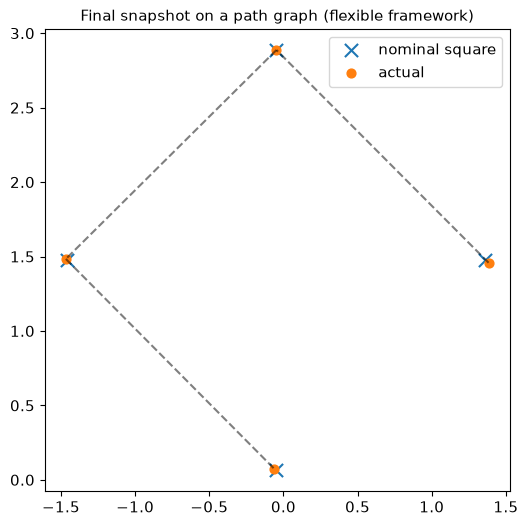

In [5]:
path_graph = CommunicationGraph.path(4)
formation_path = FormationSpec.regular_polygon(4, radius=1.41, graph=path_graph)

rank = np.linalg.matrix_rank(formation_path.rigidity_matrix())
trivial = formation_path.dim * (formation_path.dim + 1) // 2  # 3 in 2D
print(f"is_infinitesimally_rigid: {formation_path.is_infinitesimally_rigid()}")
print(
    f"rank R = {rank} (need {formation_path.n_agents * formation_path.dim - trivial} "
    f"for rigidity; {trivial} trivial motions)"
)
print(f"rigidity_eigenvalue = {formation_path.rigidity_eigenvalue():.3e}")

t = 0.1 * np.arange(60)
reference = np.column_stack([2.0 * np.cos(0.15 * t), 2.0 * np.sin(0.15 * t)])
leader_follower = LeaderFollowerSpec(leaders=(0,), reference=reference)
tracking_weights = AgentCostWeights(q_position=1.0, p_terminal=5.0)

ctrl = DistributedMPC(
    model,
    path_graph,
    formation_path,
    limits,
    tracking_weights,
    admm_options,
    MPCOptions(horizon=10, dt=0.1, n_steps=60, seed=0),
    leader_follower=leader_follower,
)
log_path = ctrl.run(x0)

plotting.plot_trajectories(log_path, formation=formation_path)
plt.show()

# The path is a flexible framework: overlay the final snapshot on the nominal square.
fig, ax = plt.subplots(figsize=(6, 6))
nominal = formation_path.target_positions(log_path.positions[-1].mean(axis=0))
ax.scatter(nominal[:, 0], nominal[:, 1], marker="x", s=90, label="nominal square")
ax.scatter(log_path.positions[-1, :, 0], log_path.positions[-1, :, 1], s=40, label="actual")
for i, j in formation_path.graph.edges:
    ax.plot(
        [log_path.positions[-1, i, 0], log_path.positions[-1, j, 0]],
        [log_path.positions[-1, i, 1], log_path.positions[-1, j, 1]],
        "k--",
        alpha=0.5,
    )
ax.set_aspect("equal", adjustable="datalim")
ax.set_title("Final snapshot on a path graph (flexible framework)")
ax.legend()
plt.show()

## Morphing

Sweep `interpolate_formations` from a line to a V during the run.

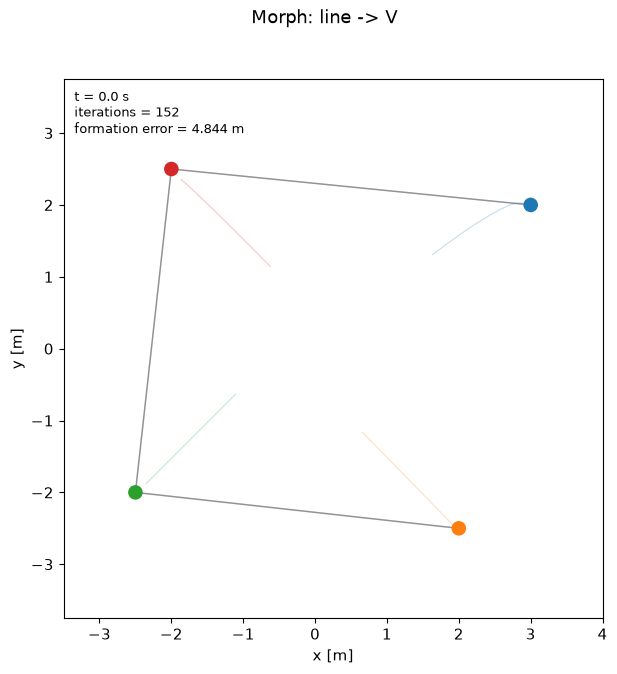

In [6]:
start = FormationSpec.line(4, spacing=1.0)
end = FormationSpec.v_shape(4, spacing=1.0)
graph = end.graph  # path


def run_morph(x0, start, end, n_steps=40):
    """Manual closed loop with time-varying offsets (the solver bakes offsets at build)."""
    horizon = 10
    dt = model.dt
    A, B = model.matrices()

    x = np.asarray(x0, dtype=np.float64).copy()
    states = np.zeros((n_steps + 1, 4, model.n_states))
    states[0] = x
    inputs = np.zeros((n_steps, 4, model.dim))
    positions = [x[:, : model.dim].copy()]
    predictions, histories, solve_times, admm_iterations, formation_errors = [], [], [], [], []

    for k in range(n_steps):
        alpha = k / (n_steps - 1)
        spec = interpolate_formations(start, end, alpha)
        offsets = {i: spec.edge_offsets(i) for i in range(4)}
        solvers = {
            i: CvxpyAgentSolver(
                agent_id=i,
                horizon=horizon,
                model=model,
                limits=limits,
                weights=formation_weights,
                neighborhood=graph.closed_neighborhood(i),
                offsets=offsets.get(i),
            )
            for i in range(4)
        }
        admm = ConsensusADMM(graph, solvers, horizon, dim=model.dim, options=admm_options)
        result = admm.solve(x, references={}, offsets=offsets)
        u = result.first_inputs()
        x = x @ A.T + u @ B.T
        states[k + 1] = x
        inputs[k] = u
        positions.append(x[:, : model.dim].copy())
        predictions.append(result.trajectories)
        histories.append(result.history)
        solve_times.append(result.solve_time)
        admm_iterations.append(result.iterations)
        formation_errors.append(formation_error(x[:, : model.dim], spec).edge_rms)

    return SimulationLog(
        time=np.arange(n_steps + 1) * dt,
        states=states,
        inputs=inputs,
        predictions=predictions,
        admm_iterations=np.array(admm_iterations),
        admm_converged=np.ones(n_steps, dtype=bool),
        formation_error=np.array(formation_errors),
        graphs=[graph] * n_steps,
        histories=histories,
        solve_times=np.array(solve_times),
    )


log_morph = run_morph(x0, start, end, n_steps=40)
plotting.animate_formation(
    log_morph, show_graph=True, show_predictions=True, title="Morph: line -> V"
)

## Eight agents

Scale to 8 in a two-row grid; report iteration count and wall time versus the 4-agent case.

8-agent grid summary:
{'mean_admm_iterations': 5.316666666666666, 'max_admm_iterations': 138.0, 'final_formation_error': 0.01387164531106439, 'settling_step': 24.0, 'total_solve_time': 7.0856889489932655, 'convergence_failures': 0.0}


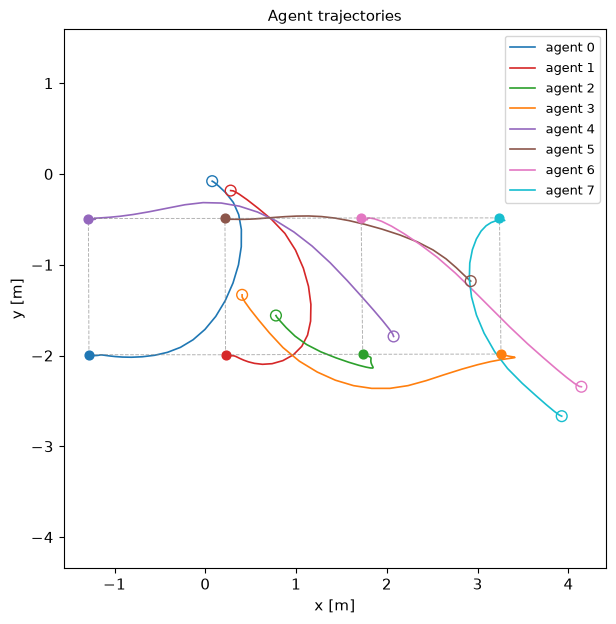

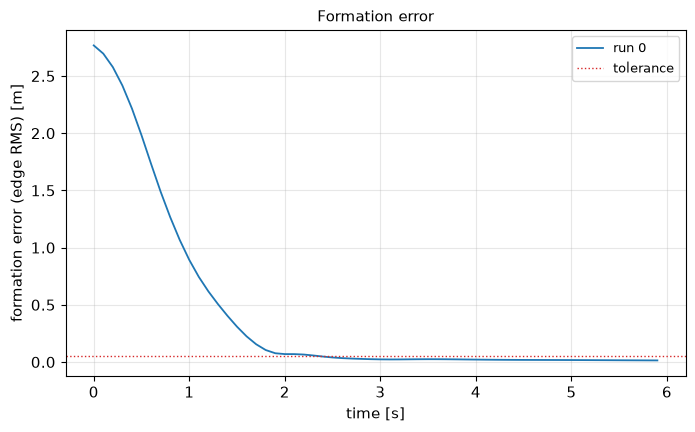

saved /repo/media/8_agent_grid.gif
4-agent square summary (for comparison):
{'mean_admm_iterations': 5.35, 'max_admm_iterations': 142.0, 'final_formation_error': 0.00695987681037041, 'settling_step': 19.0, 'total_solve_time': 3.601216487999409, 'convergence_failures': 0.0}


In [7]:
formation8 = FormationSpec.grid(2, 4, spacing=1.5)
graph8 = formation8.graph

# A wider scatter for 8 agents.
x0_8 = rng.normal(scale=0.6, size=(8, model.n_states))
x0_8[:, model.dim :] *= 0.2
x0_8[:, : model.dim] += np.array([0.6, -0.4]) * np.arange(8)[:, None]

mpc8 = DistributedMPC(
    model,
    graph8,
    formation8,
    limits,
    formation_weights,
    ADMMOptions(rho=1.0, max_iterations=500, eps_abs=2e-2, eps_rel=2e-2),
    MPCOptions(horizon=10, dt=0.1, n_steps=60, seed=0),
)
log8 = mpc8.run(x0_8)

print("8-agent grid summary:")
print(log8.summary())
plotting.plot_trajectories(log8, formation=formation8)
plt.show()
plotting.plot_formation_error(log8, tolerance=0.05)
plt.show()

# Second README asset: the same controller at 8 agents on a 4-neighbour lattice, which
# is where the graph structure actually shows up in the picture (the 4-agent cycle looks
# like a square whatever the topology is).
anim8 = plotting.animate_formation(
    log8, formation=formation8, show_graph=True, show_predictions=True,
    title="Eight agents, 2x4 grid",
)
plotting.save_animation(anim8, str(repo_root / "media" / "8_agent_grid.gif"))
print(f"saved {repo_root / 'media' / '8_agent_grid.gif'}")
plt.close(anim8._fig)

print("4-agent square summary (for comparison):")
print(log_square.summary())

## Takeaway

Relative-offset costs are enough to build rigid formations; the communication graph sets the convergence speed and the formation graph sets whether the shape is unique.